In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
df_sber = pd.read_csv("..\\data\\order_books\\SBER_10.csv", header=0)
df_sber['SBER'] = df_sber['MidPriceClose'].pct_change()
#df_sber['log_rtn'] = np.log(df_sber['MidPriceClose']/df_sber['MidPriceClose'].shift(1))
df_sber.drop(columns=['MidPriceClose', 'MidPriceAvg', 'MidPriceStdDev', 'SpreadAvg', 'Count'], inplace=True)

df_srh6 = pd.read_csv("..\\data\\order_books\\SRH6_10.csv", header=0)
df_srh6['SBRF-3.26'] = df_srh6['MidPriceClose'].pct_change()
df_srh6.drop(columns=['MidPriceClose', 'MidPriceAvg', 'MidPriceStdDev', 'SpreadAvg', 'Count'], inplace=True)

df_srm6 = pd.read_csv("..\\data\\order_books\\SRM6_10.csv", header=0)
df_srm6['SBRF-6.26'] = df_srm6['MidPriceClose'].pct_change()
df_srm6.drop(columns=['MidPriceClose', 'MidPriceAvg', 'MidPriceStdDev', 'SpreadAvg', 'Count'], inplace=True)

df_sru6 = pd.read_csv("..\\data\\order_books\\SRU6_10.csv", header=0)
df_sru6['SBRF-9.26'] = df_sru6['MidPriceClose'].pct_change()
df_sru6.drop(columns=['MidPriceClose', 'MidPriceAvg', 'MidPriceStdDev', 'SpreadAvg', 'Count'], inplace=True)

df1 = pd.merge(df_sber, df_srh6, on='TimeUtc')
df2 = pd.merge(df1, df_srm6, on='TimeUtc')
df = pd.merge(df2, df_sru6, on='TimeUtc')
df.dropna(inplace=True)


In [48]:
df

,TimeUtc,SBER,SBRF-3.26,SBRF-6.26,SBRF-9.26
1,03/17/2026 06:42:50,0.000000,0.000000,0.000000,0.000000
2,03/17/2026 06:43:00,0.000380,0.000142,0.000137,0.000000
3,03/17/2026 06:43:10,0.000016,0.000237,0.000228,0.000610
4,03/17/2026 06:43:20,-0.000016,0.000000,-0.000015,-0.000016
5,03/17/2026 06:43:30,0.000000,0.000016,0.000000,0.000000
...,...,...,...,...,...
2877,03/17/2026 15:45:40,0.000000,0.000016,0.000000,0.000000
2878,03/17/2026 15:45:50,0.000000,-0.000047,-0.000091,0.000000
2879,03/17/2026 15:46:00,0.000000,0.000126,0.000166,0.000016
2880,03/17/2026 15:46:10,0.000000,0.000047,0.000045,0.000016


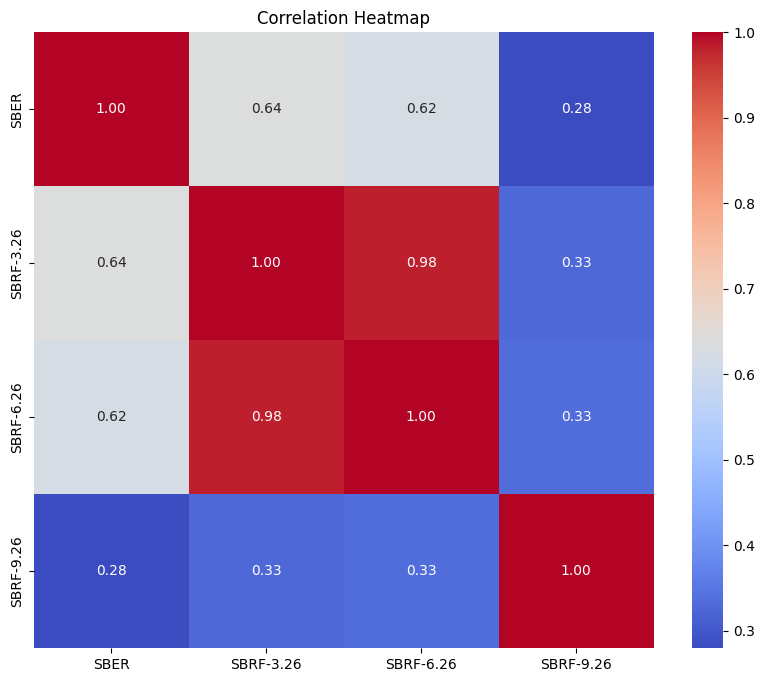

In [49]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap')
plt.show()
